<a href="https://colab.research.google.com/github/SuchandanG/Optimized-Secure-Admissible-Partitioning-of-Affine-Manifolds-for-General-Access-Structures/blob/main/PartvsMSP_Table.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##MSP Table

In [ ]:
import numpy as np
from itertools import combinations
import time  # Imported for tracking execution time

# ============================================================
# INPUT ACCESS STRUCTURE
# ============================================================

participants = ["P1", "P2", "P3", "P4"]

access_structures = [
    [{"P1","P2"}], # Case 1
    [{"P1","P2"}, {"P2","P3"}], # Case 2
    [{"P1","P2"}, {"P1","P3"}, {"P2","P3"}], # Case 3
    [{"P1","P2"}, {"P2","P3"}, {"P3","P4"}], # Case 4
    [{"P1","P2"}, {"P1","P3"}, {"P1","P4"}], # Case 5
    [{"P1","P2"}, {"P1","P4"}, {"P2","P3"}, {"P3","P4"}], # Case 6
    [{"P1","P2"}, {"P2","P3"}, {"P2","P4"}, {"P3","P4"}], # Case 7
    [{"P1","P2"}, {"P1","P3"}, {"P1","P4"}, {"P2","P3"}, {"P2","P4"}], # Case 8
    [{"P1","P2"}, {"P1","P3"}, {"P1","P4"}, {"P2","P3"}, {"P2","P4"}, {"P3","P4"}], # Case 9
    [{"P1","P2","P3"}, {"P1","P4"}], # Case 10
    [{"P1","P3","P4"}, {"P1","P2"}, {"P2","P3"}, {"P2","P4"}], # Case 11
    [{"P1","P2","P4"}, {"P1","P3","P4"}, {"P2","P3"}], # Case 12
    [{"P1","P2","P3"}, {"P1","P2","P4"}, {"P1","P3","P4"}], # Case 13
    [{"P1","P2","P3"}, {"P1","P2","P4"}, {"P1","P3","P4"}, {"P2","P3","P4"}], # Case 14
    [{"P1","P2","P3","P4"}] # Case 15
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def generate_forbidden_sets(participants, qualified_sets):
    all_sets = []
    for r in range(1, len(participants) + 1):
        for s in combinations(participants, r):
            all_sets.append(set(s))

    forbidden_sets = []
    for A in all_sets:
        qualified = False
        for Q in qualified_sets:
            if Q.issubset(A):
                qualified = True
                break
        if not qualified:
            forbidden_sets.append(A)
    return forbidden_sets


def spans_target(rows, target):
    if len(rows) == 0:
        return False
    rows = np.array(rows) % 2
    n = len(rows)

    for mask in range(1 << n):
        s = np.zeros(len(target), dtype=int)
        for i in range(n):
            if (mask >> i) & 1:
                s ^= rows[i]
        if np.array_equal(s % 2, target):
            return True
    return False


def random_vector(d, target):
    while True:
        v = np.random.randint(0, 2, size=d)
        if not np.array_equal(v, target):
            return v


def build_candidate(total_rows, dimension, target, participants):
    rows = []
    labels = []
    for _ in range(total_rows):
        rows.append(random_vector(dimension, target))
        labels.append(np.random.choice(participants))
    return np.array(rows), labels


def rows_for_subset(M, labels, subset):
    return [r for r, p in zip(M, labels) if p in subset]


def verify_msp(M, labels, qualified_sets, forbidden_sets, target):
    for A in qualified_sets:
        if not spans_target(rows_for_subset(M, labels, A), target):
            return False
    for B in forbidden_sets:
        if spans_target(rows_for_subset(M, labels, B), target):
            return False
    return True


def remove_same_party_duplicates(M, labels):
    new_rows, new_labels, seen = [], [], set()
    for row, lab in zip(M, labels):
        key = (lab, tuple(row))
        if key not in seen:
            seen.add(key)
            new_rows.append(row)
            new_labels.append(lab)
    return np.array(new_rows), new_labels

# ============================================================
# SEARCH PARAMETERS
# ============================================================
FIELD = 2
MAX_TRIALS = 50000

results = []

# ============================================================
# RUN JOINT SEARCH (ROWS & COLUMNS)
# ============================================================
for case_number, qualified_sets in enumerate(access_structures, start=1):
    print("\n" + "="*70)
    print(f"CASE {case_number}")
    print("="*70)
    print(f"Qualified Sets: { [list(q) for q in qualified_sets] }")

    start_time = time.time() # Start timing for the current case

    forbidden_sets = generate_forbidden_sets(participants, qualified_sets)

    active_parties = set().union(*qualified_sets)
    min_share_expansion = len(active_parties)

    print(f"Optimized Search: Testing combinations of Rows (from {min_share_expansion}) and Dimensions (from 2)")
    found = False

    for share_expansion in range(min_share_expansion, 10):
        for dimension in range(2, 6):

            target = np.zeros(dimension, dtype=int)
            target[0] = 1

            print(f"  Testing Matrix Size: {share_expansion} Rows x {dimension} Columns...    ", end="\r")

            for trial in range(MAX_TRIALS):
                M, labels = build_candidate(share_expansion, dimension, target, participants)

                if verify_msp(M, labels, qualified_sets, forbidden_sets, target):
                    reduced_M, reduced_labels = remove_same_party_duplicates(M, labels)

                    if verify_msp(reduced_M, reduced_labels, qualified_sets, forbidden_sets, target):
                        found = True
                        elapsed_time = time.time() - start_time
                        print(f"\n  [SUCCESS] Found optimized MSP!")
                        print(f"  Rows: {share_expansion} (Reduced to {len(reduced_labels)}) | Vector Dim: {dimension}")
                        print(f"  Execution Time: {elapsed_time:.4f} sec")

                        print("\n  [Generated Monotone Span Program Matrix]")
                        for label, row in zip(reduced_labels, reduced_M):
                            print(f"    {label} : {row.tolist()}")

                        results.append((case_number, share_expansion, len(reduced_labels), dimension, elapsed_time))
                        break
            if found:
                break
        if found:
            break

    if not found:
        elapsed_time = time.time() - start_time
        print(f"\n  No valid MSP found within execution limits.")
        print(f"  Execution Time: {elapsed_time:.4f} sec")
        results.append((case_number, "N/A", "Not Found", "N/A", elapsed_time))

# ============================================================
# SUMMARY REPORT
# ============================================================
print("\n" + "="*95)
print(f"{'CASE':<6} | {'ORIGINAL ROWS':<15} | {'REDUCED ROWS':<15} | {'OPTIMIZED VECTOR DIM':<22} | {'EXECUTION TIME (s)':<18}")
print("="*95)
for case, orig, red, dim, elapsed in results:
    elapsed_str = f"{elapsed:.4f}" if isinstance(elapsed, float) else str(elapsed)
    print(f"{case:<6} | {str(orig):<15} | {str(red):<15} | {str(dim):<22} | {elapsed_str:<18}")
print("="*95)


CASE 1
Qualified Sets: [['P1', 'P2']]
Optimized Search: Testing combinations of Rows (from 2) and Dimensions (from 2)
  Testing Matrix Size: 2 Rows x 2 Columns...    
  [SUCCESS] Found optimized MSP!
  Rows: 2 (Reduced to 2) | Vector Dim: 2
  Execution Time: 0.0145 sec

  [Generated Monotone Span Program Matrix]
    P2 : [0, 1]
    P1 : [1, 1]

CASE 2
Qualified Sets: [['P1', 'P2'], ['P2', 'P3']]
Optimized Search: Testing combinations of Rows (from 3) and Dimensions (from 2)
  Testing Matrix Size: 3 Rows x 2 Columns...    
  [SUCCESS] Found optimized MSP!
  Rows: 3 (Reduced to 3) | Vector Dim: 2
  Execution Time: 0.0127 sec

  [Generated Monotone Span Program Matrix]
    P3 : [0, 1]
    P1 : [0, 1]
    P2 : [1, 1]

CASE 3
Qualified Sets: [['P1', 'P2'], ['P1', 'P3'], ['P2', 'P3']]
Optimized Search: Testing combinations of Rows (from 3) and Dimensions (from 2)
  Testing Matrix Size: 5 Rows x 3 Columns...    
  [SUCCESS] Found optimized MSP!
  Rows: 5 (Reduced to 5) | Vector Dim: 3
  Exec

##Partitioning Table

In [ ]:
from itertools import combinations
import time

# =========================================================
# 15 TEST CASES FOR ACCESS STRUCTURES
# =========================================================

access_structures_cases = [
    [frozenset({1, 2})],
    [frozenset({1, 2}), frozenset({2, 3})],
    [frozenset({1, 2}), frozenset({1, 3}), frozenset({2, 3})],
    [frozenset({1, 2}), frozenset({2, 3}), frozenset({3, 4})],
    [frozenset({1, 2}), frozenset({1, 3}), frozenset({1, 4})],
    [frozenset({1, 2}), frozenset({1, 4}), frozenset({2, 3}), frozenset({3, 4})],
    [frozenset({1, 2}), frozenset({2, 3}), frozenset({2, 4}), frozenset({3, 4})],
    [frozenset({1, 2}), frozenset({1, 3}), frozenset({1, 4}), frozenset({2, 3}), frozenset({2, 4})],
    [frozenset({1, 2}), frozenset({1, 3}), frozenset({1, 4}), frozenset({2, 3}), frozenset({2, 4}), frozenset({3, 4})],
    [frozenset({1, 2, 3}), frozenset({1, 4})],
    [frozenset({1, 3, 4}), frozenset({1, 2}), frozenset({2, 3}), frozenset({2, 4})],
    [frozenset({1, 2, 4}), frozenset({1, 3, 4}), frozenset({2, 3})],
    [frozenset({1, 2, 3}), frozenset({1, 2, 4}), frozenset({1, 3, 4})],
    [frozenset({1, 2, 3}), frozenset({1, 2, 4}), frozenset({1, 3, 4}), frozenset({2, 3, 4})],
    [frozenset({1, 2, 3, 4})]
]

# =========================================================
# HELPER CORE LOGIC FUNCTIONS
# =========================================================

def local_intersection(subfamily):
    return set.intersection(*map(set, subfamily))

def quotient_residuals(subfamily, S):
    return [set(A) - S for A in subfamily]

def satisfies_kSC(residuals):
    k = len(residuals)
    for i in range(k):
        ok = True
        for j in range(k):
            if i == j: continue
            if residuals[i].intersection(residuals[j]):
                ok = False
                break
        if ok: return True
    return False

def xor_support(subfamily):
    count = {}
    for A in subfamily:
        for x in A:
            count[x] = count.get(x, 0) + 1
    return frozenset([x for x in count if count[x] % 2 == 1])

def monotone_qualified(B, Gamma_0):
    for A in Gamma_0:
        if set(A).issubset(set(B)): return True
    return False

def admissible_family(family, Gamma_0):
    n = len(family)
    for k in range(3, n + 1, 2):
        for sub in combinations(family, k):
            S = local_intersection(sub)
            residuals = quotient_residuals(sub, S)
            if not satisfies_kSC(residuals):
                B = xor_support(sub)
                if not monotone_qualified(B, Gamma_0): return False
    return True

def generated_by_family(B, family):
    n = len(family)
    for k in range(3, n + 1, 2):
        for sub in combinations(family, k):
            if xor_support(sub) == B: return True
    return False

def reduce_block(block):
    generators = list(block)
    derived = set()
    changed = True
    while changed:
        changed = False
        for B in generators.copy():
            others = [A for A in generators if A != B]
            if generated_by_family(B, others):
                generators.remove(B)
                derived.add(B)
                changed = True
                break
    return generators, derived

def block_support(block):
    S = set()
    for A in block: S |= set(A)
    return S

def share_expansion_cost(partition):
    return sum(len(block_support(block)) for block in partition)

def format_block(block):
    formatted = []
    for A in sorted(block, key=lambda x: sorted(list(x))):
        formatted.append("{" + ",".join(map(lambda x: f"P{x}", sorted(A))) + "}")
    return ", ".join(formatted)

def all_partitions(collection):
    if len(collection) == 1:
        yield [collection]
        return
    first = collection[0]
    for smaller in all_partitions(collection[1:]):
        for n, subset in enumerate(smaller):
            yield smaller[:n] + [[first] + subset] + smaller[n + 1:]
        yield [[first]] + smaller

def admissible_partition(partition, Gamma_0):
    reduced_partition = []
    all_derived = set()
    for block in partition:
        if not admissible_family(block, Gamma_0):
            return False, [], set()
        reduced, derived = reduce_block(block)
        reduced_partition.append(reduced)
        all_derived |= derived
    return True, reduced_partition, all_derived

def globally_optimal_partition(Gamma_input):
    Gamma_0 = set(Gamma_input)
    best_partition, best_derived, best_cost = None, set(), None
    checked = admissible_count = 0

    for partition in all_partitions(list(Gamma_0)):
        checked += 1
        admissible, reduced_partition, derived_sets = admissible_partition(partition, Gamma_0)
        if admissible:
            admissible_count += 1
            cost = share_expansion_cost(reduced_partition)
            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_partition = reduced_partition
                best_derived = derived_sets

    return best_partition, best_derived, best_cost, checked, admissible_count

# =========================================================
# RUN EXECUTIONS & COLLECT RESULTS
# =========================================================

summary_results = []

for idx, Gamma in enumerate(access_structures_cases, start=1):
    print(f"Processing Case {idx:02d}...", end="\r")

    start_time = time.perf_counter()
    result, derived, cost, checked, admissible_count = globally_optimal_partition(Gamma)
    end_time = time.perf_counter()

    # Format the original structured input
    input_str = " | ".join(["{" + ",".join(map(lambda x: f"P{x}", sorted(A))) + "}" for A in Gamma])

    # Format the optimized sub-blocks separated by " || "
    partition_blocks = [f"Γ_{i+1}=[{format_block(b)}]" for i, b in enumerate(result)]
    partition_str = " || ".join(partition_blocks)

    summary_results.append({
        "case": idx,
        "structure": input_str,
        "partition": partition_str,
        "cost": cost,
        "time": end_time - start_time
    })

# =========================================================
# SUMMARY REPORT
# =========================================================

print("\n" + "="*145)
print(f"{'CASE':<5} | {'OPTIMIZED PARTITION SUB-BLOCKS':<70} | {'C(Pi*)':<8} | {'EXECUTION TIME (s)':<18}")
print("="*145)
for res in summary_results:
    print(f"{res['case']:<5} | {res['partition']:<70} | {res['cost']:<8} | {res['time']:<18.6f}")
print("="*145)

Processing Case 15...
CASE  | OPTIMIZED PARTITION SUB-BLOCKS                                         | C(Pi*)   | EXECUTION TIME (s)
1     | Γ_1=[{P1,P2}]                                                          | 2        | 0.000028          
2     | Γ_1=[{P1,P2}, {P2,P3}]                                                 | 3        | 0.000041          
3     | Γ_1=[{P1,P3}] || Γ_2=[{P1,P2}, {P2,P3}]                                | 5        | 0.000110          
4     | Γ_1=[{P3,P4}] || Γ_2=[{P1,P2}, {P2,P3}]                                | 5        | 0.000080          
5     | Γ_1=[{P1,P2}, {P1,P3}, {P1,P4}]                                        | 4        | 0.000071          
6     | Γ_1=[{P1,P2}, {P1,P4}, {P2,P3}]                                        | 4        | 0.000314          
7     | Γ_1=[{P3,P4}] || Γ_2=[{P1,P2}, {P2,P3}, {P2,P4}]                       | 6        | 0.000225          
8     | Γ_1=[{P1,P2}] || Γ_2=[{P1,P3}, {P2,P3}, {P2,P4}]                       | 6        

## The Plot

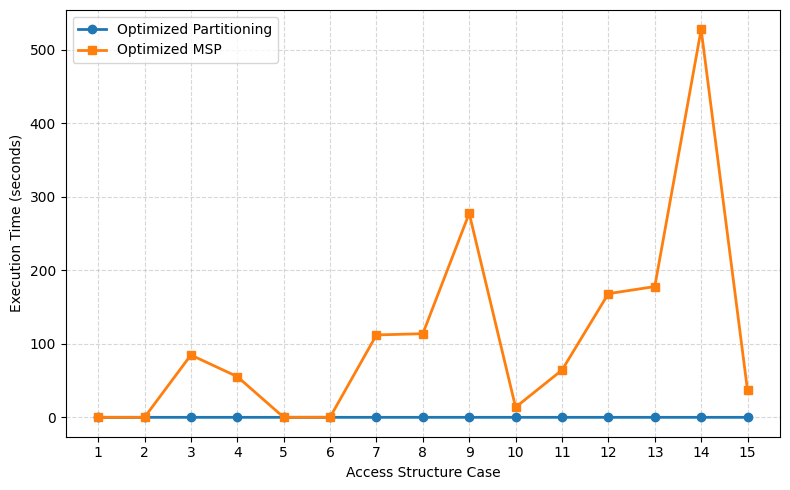

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Data from Table 1
# -------------------------------------------------------

cases = list(range(1, 16))

partition_time = [
    0.000028,
    0.000041,
    0.000110,
    0.000080,
    0.000071,
    0.000314,
    0.000225,
    0.000999,
    0.005226,
    0.000031,
    0.000243,
    0.000073,
    0.000069,
    0.000226,
    0.000011
]

msp_time = [
    0.0145,
    0.0127,
    84.7254,
    55.3632,
    0.0693,
    0.1012,
    112.0315,
    113.7151,
    277.3695,
    13.7359,
    64.2080,
    168.1667,
    177.7887,
    527.5032,
    36.5952
]

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    cases,
    partition_time,
    marker='o',
    linewidth=2,
    markersize=6,
    label='Optimized Partitioning'
)

plt.plot(
    cases,
    msp_time,
    marker='s',
    linewidth=2,
    markersize=6,
    label='Optimized MSP'
)

plt.xlabel("Access Structure Case")
plt.ylabel("Execution Time (seconds)")
plt.xticks(cases)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("runtime_comparison.pdf", dpi=600)
plt.savefig("runtime_comparison.png", dpi=600)

plt.show()

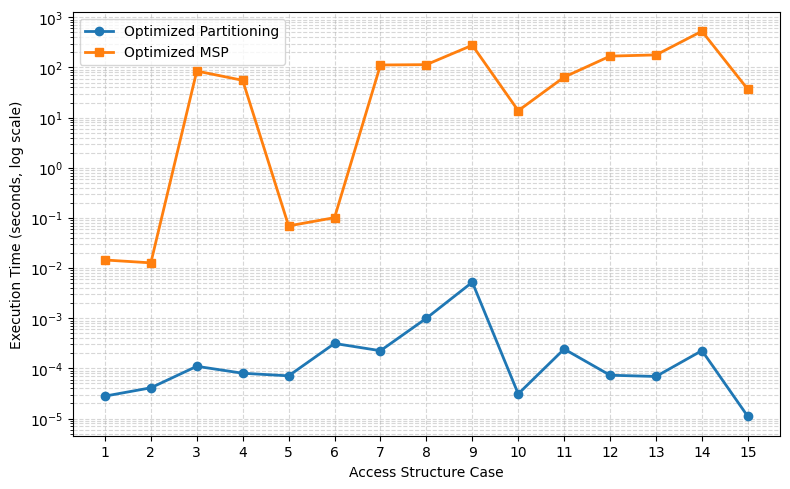

In [ ]:
plt.figure(figsize=(8,5))

plt.semilogy(
    cases,
    partition_time,
    marker='o',
    linewidth=2,
    markersize=6,
    label='Optimized Partitioning'
)

plt.semilogy(
    cases,
    msp_time,
    marker='s',
    linewidth=2,
    markersize=6,
    label='Optimized MSP'
)

plt.xlabel("Access Structure Case")
plt.ylabel("Execution Time (seconds, log scale)")
plt.xticks(cases)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("runtime_comparison_log.pdf", dpi=600)
plt.savefig("runtime_comparison_log.png", dpi=600)

plt.show()

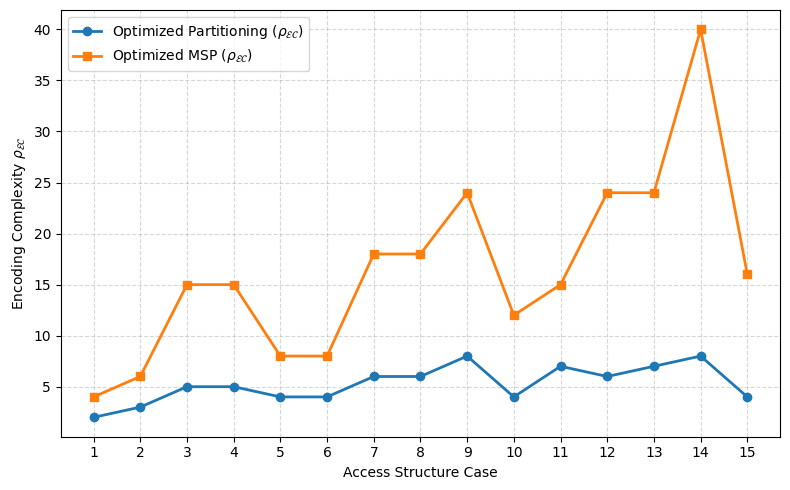

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Data from Table 1
# -------------------------------------------------------

cases = list(range(1, 16))

rho_partition = [
    2,
    3,
    5,
    5,
    4,
    4,
    6,
    6,
    8,
    4,
    7,
    6,
    7,
    8,
    4
]

rho_msp = [
    4,
    6,
    15,
    15,
    8,
    8,
    18,
    18,
    24,
    12,
    15,
    24,
    24,
    40,
    16
]

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    cases,
    rho_partition,
    marker='o',
    linewidth=2,
    markersize=6,
    label=r'Optimized Partitioning ($\rho_{\mathcal{EC}}$)'
)

plt.plot(
    cases,
    rho_msp,
    marker='s',
    linewidth=2,
    markersize=6,
    label=r'Optimized MSP ($\rho_{\mathcal{EC}}$)'
)

plt.xlabel("Access Structure Case")
plt.ylabel(r"Encoding Complexity $\rho_{\mathcal{EC}}$")
plt.xticks(cases)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()

plt.savefig("en_complexity_comparison.pdf", dpi=600)
plt.savefig("en_complexity_comparison.png", dpi=600)

plt.show()